In [1]:
import pandas as pd
import os
from glob import glob
from datetime import datetime
from sqlalchemy import create_engine
from dotenv import load_dotenv


In [2]:
df_rvi = pd.read_csv('./data/rvi_timeseries.csv')
df_vv = pd.read_csv('./data/vv_timeseries.csv')
df_vh = pd.read_csv('./data/vh_timeseries.csv')
df_vvhh = pd.read_csv('./data/vv_vh_ratio_timeseries.csv')

In [3]:
dfs = [df_vv, df_vh, df_vvhh, df_rvi]

for df in dfs:
    df['date'] = pd.to_datetime(df['time']).dt.strftime('%Y-%m-%d')
    df.drop(columns='time', inplace = True)
    date_col = df.pop('date')
    df.insert(0, 'date', date_col)

RangeIndex(start=0, stop=15, step=1)

In [23]:
tst = pd.concat(dfs, axis = 1, join = 'outer').T.drop_duplicates().T
tst

,date,vv,vh,vv_vh_ratio,rvi
0,2025-01-06,-8.844509,-14.869054,0.592938,-7.786224
1,2025-01-18,-8.408583,-14.247108,0.584143,-6.976769
2,2025-01-30,-9.179759,-14.944003,0.604938,-7.924891
3,2025-02-11,-8.464668,-14.211534,0.585472,-6.901273
4,2025-02-23,-8.757017,-14.348061,0.596804,-7.098228
5,2025-03-07,-8.652385,-14.50922,0.582237,-7.169673
6,2025-03-19,-8.760703,-14.488021,0.592125,-7.143175
7,2025-03-31,-8.621548,-14.317022,0.58664,-6.988633
8,2025-04-12,-8.523388,-14.273334,0.582745,-6.796845
9,2025-04-24,-8.485248,-14.043196,0.590779,-6.687039


In [37]:
#not beautiful, but it works
df  = df_vv.merge(
            df_vh.merge(
                df_vvhh.merge(
                    df_rvi, on = 'date', how = 'left'), 
                on = 'date', how = 'left'), 
            on = 'date', how = 'left', validate="many_to_many")

In [38]:
df

,date,vv,vh,vv_vh_ratio,rvi
0,2025-01-06,-8.844509,-14.869054,0.592938,-7.786224
1,2025-01-18,-8.408583,-14.247108,0.584143,-6.976769
2,2025-01-30,-9.179759,-14.944003,0.604938,-7.924891
3,2025-02-11,-8.464668,-14.211534,0.585472,-6.901273
4,2025-02-23,-8.757017,-14.348061,0.596804,-7.098228
5,2025-03-07,-8.652385,-14.509220,0.582237,-7.169673
6,2025-03-19,-8.760703,-14.488021,0.592125,-7.143175
7,2025-03-31,-8.621548,-14.317022,0.586640,-6.988633
8,2025-04-12,-8.523388,-14.273334,0.582745,-6.796845
9,2025-04-24,-8.485248,-14.043196,0.590779,-6.687039


In [39]:
df['terrai_id'] = 40301

In [24]:
load_dotenv()

database = os.environ.get("POSTGRES_DB")
user = os.environ.get('POSTGRES_USER')
password = os.environ.get('POSTGRES_PASSWORD')
host = '127.0.0.1'
port = 5434

def get_connection():
    return create_engine(
        url = f"postgresql://{user}:{password}@{host}:{port}/{database}"
    )

conn = get_connection()

In [44]:
df.to_sql(
    name = 'satellite_timeseries',
    con = conn, 
    if_exists = 'append',
    index = False
)

15

In [55]:
df = pd.read_sql(
    sql = "SELECT * FROM satellite_timeseries AS st;",
    con = conn
)

df

,date,vv,vh,vv_vh_ratio,rvi,terrai_id
0,2025-01-06,-8.844509,-14.869054,0.592938,-7.786224,40301
1,2025-01-18,-8.408583,-14.247108,0.584143,-6.976769,40301
2,2025-01-30,-9.179759,-14.944003,0.604938,-7.924891,40301
3,2025-02-11,-8.464668,-14.211534,0.585472,-6.901273,40301
4,2025-02-23,-8.757017,-14.348061,0.596804,-7.098228,40301
5,2025-03-07,-8.652385,-14.509220,0.582237,-7.169673,40301
6,2025-03-19,-8.760703,-14.488021,0.592125,-7.143175,40301
7,2025-03-31,-8.621548,-14.317022,0.586640,-6.988633,40301
8,2025-04-12,-8.523388,-14.273334,0.582745,-6.796845,40301
9,2025-04-24,-8.485248,-14.043196,0.590779,-6.687039,40301


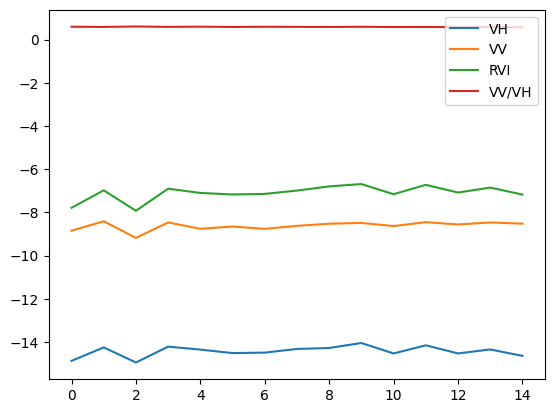

In [57]:
import matplotlib.pyplot as plt
plt.plot(df['vh'])
plt.plot(df['vv'])
plt.plot(df['rvi'])
plt.plot(df['vv_vh_ratio'])
plt.legend(['VH', 'VV', 'RVI', 'VV/VH'])

In [65]:
1 - (df['vv_vh_ratio'].iloc[0] / df['vv_vh_ratio'].iloc[-1] )

np.float64(-0.03889077941386154)